In [3]:
# ================================
# 1. IMPORT REQUIRED LIBRARIES
# ================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
# ================================
# 2. LOAD DATASET
# ================================

file_path = "telco_churn.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

Dataset loaded successfully.
Number of rows    : 7043
Number of columns : 21


In [5]:
# ================================
# 3. DATASET AUDIT
# ================================

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nData Types:")
display(df.dtypes.to_frame(name="Data Type"))

print("\nDataset Information:")
df.info()

Dataset Shape:
(7043, 21)

First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Data Types:


,Data Type
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null

In [6]:
# ================================
# MISSING VALUE AUDIT
# ================================

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage": (missing_values / len(df)) * 100
})

display(
    missing_summary
    .sort_values("Missing Count", ascending=False)
)

,Missing Count,Missing Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


In [7]:
# ================================
# CHECK TOTALCHARGES :(This dataset has an important data-quality issue: TotalCharges is stored as an object/string rather than numeric.)
# ================================

print("TotalCharges data type:", df["TotalCharges"].dtype)

blank_total_charges = (
    df["TotalCharges"].astype(str).str.strip() == ""
).sum()

print("Blank TotalCharges values:", blank_total_charges)

TotalCharges data type: str
Blank TotalCharges values: 11


In [8]:
# Display rows having blank TotalCharges
blank_rows = df[
    df["TotalCharges"].astype(str).str.strip() == ""
]

display(
    blank_rows[
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
    ]
)

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [9]:
# ================================
# CONVERT TOTALCHARGES TO NUMERIC(cleaning)
# ================================

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing TotalCharges after conversion:")
print(df["TotalCharges"].isnull().sum())

Missing TotalCharges after conversion:
11


In [10]:
# Fill TotalCharges missing values with 0
# Justification: these records correspond to customers with tenure = 0.

df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Missing TotalCharges after treatment:",
      df["TotalCharges"].isnull().sum())

Missing TotalCharges after treatment: 0


Why did we replace these values with zero?

"After investigating the missing records, I found that all of them had tenure equal to zero. Since TotalCharges represents accumulated customer charges, zero accumulated charges is a reasonable domain-based treatment for these records."


In [11]:
# ================================
# DUPLICATE CHECK
# ================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


In [12]:
# ================================
# TARGET DISTRIBUTION(The dataset is a binary classification problem.)
# ================================

print("Target Distribution:")
display(df["Churn"].value_counts())

print("\nTarget Distribution (%):")
display(
    (df["Churn"].value_counts(normalize=True) * 100)
    .round(2)
)

Target Distribution:


Churn
No     5174
Yes    1869
Name: count, dtype: int64


Target Distribution (%):


Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

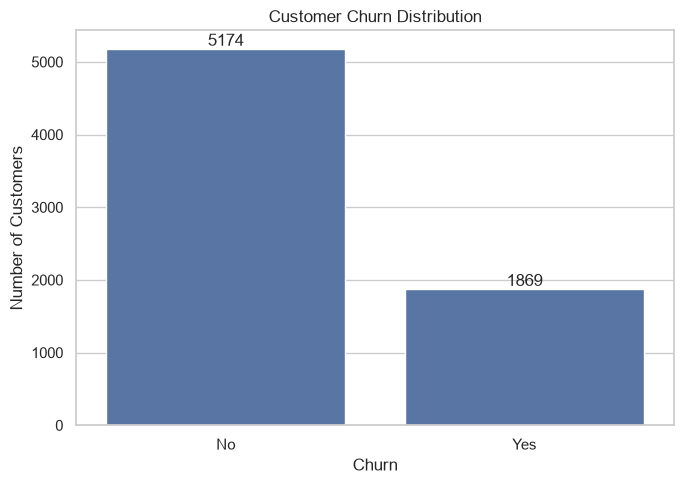

In [13]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Observation

The target variable contains two classes: `Yes` and `No`.
The classes are not perfectly balanced, with the non-churn class
representing the larger proportion of customers.

Therefore, accuracy alone may not provide a complete picture of model
performance. Weighted F1-score, precision, recall and ROC-AUC are also
considered.

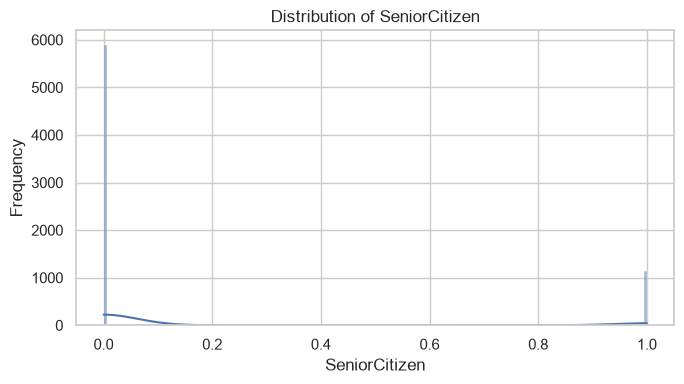

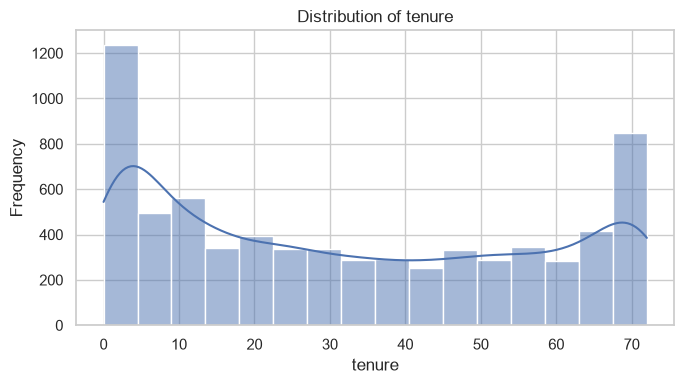

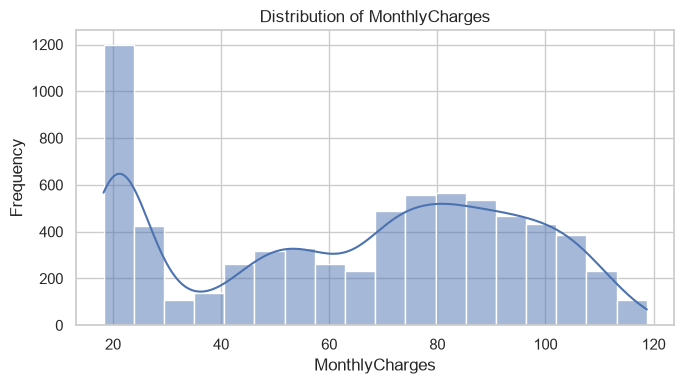

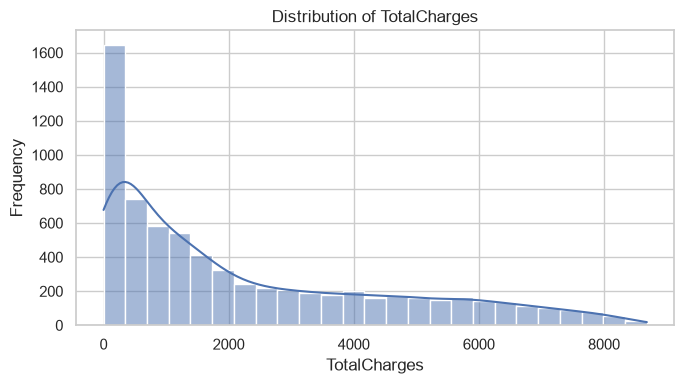

In [14]:
# ================================
# NUMERICAL FEATURE DISTRIBUTIONS
#The numerical variables are:SeniorCitizen , tenure ,MonthlyCharges ,TotalCharges
# ================================

numerical_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for feature in numerical_features:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=feature,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

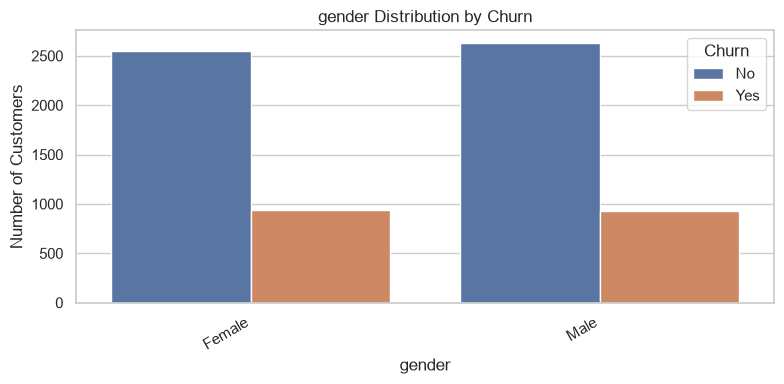

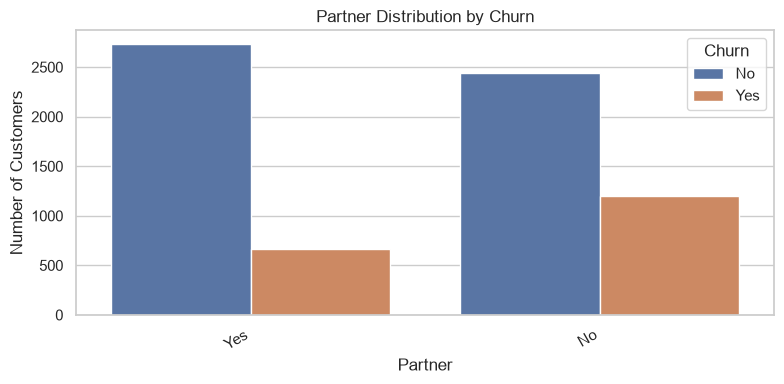

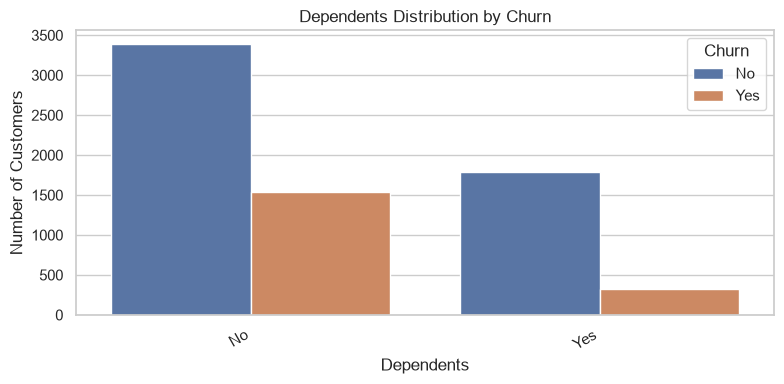

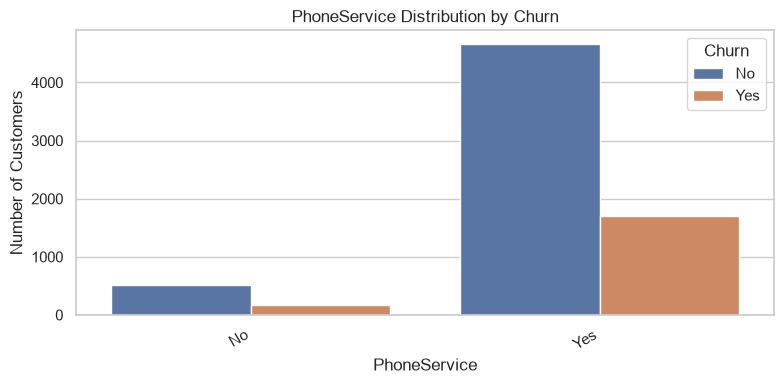

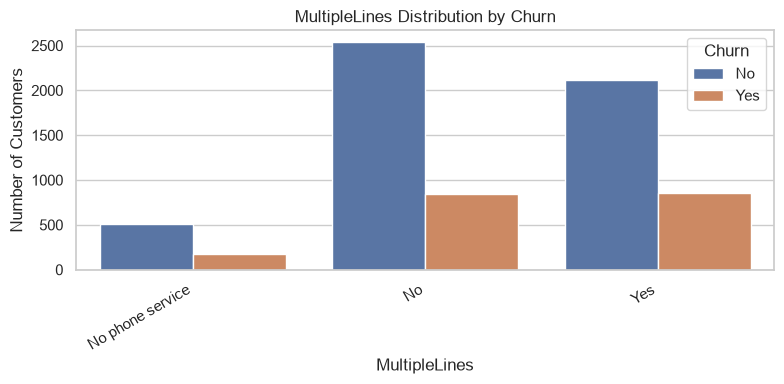

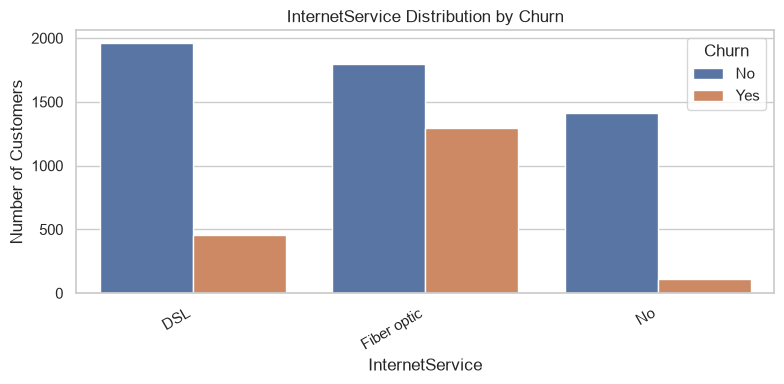

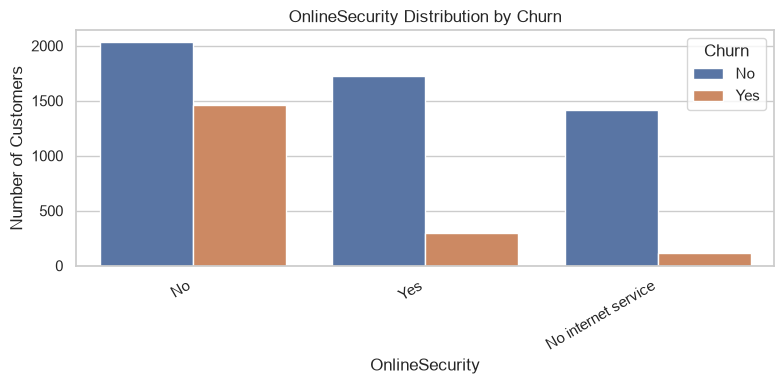

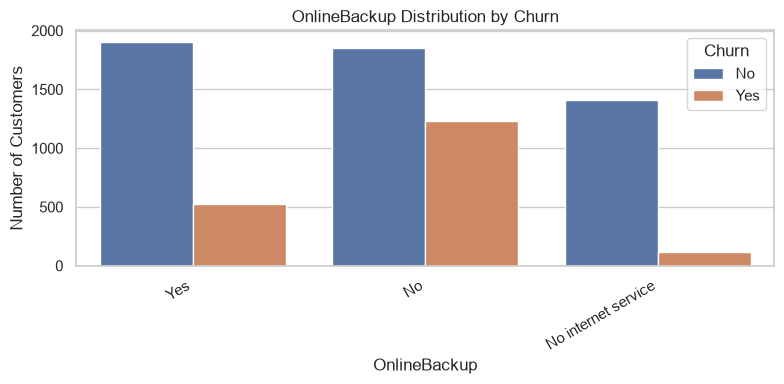

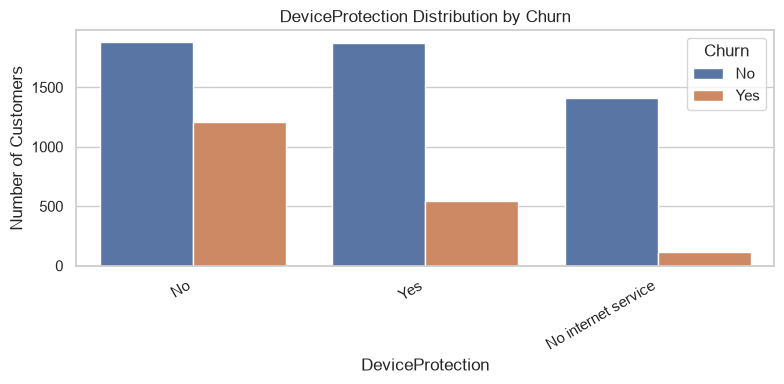

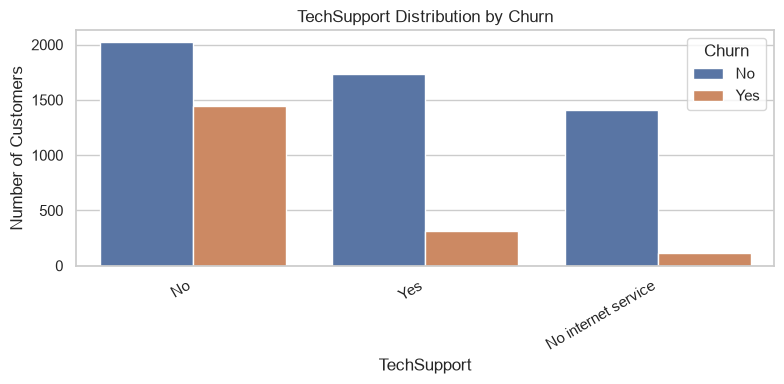

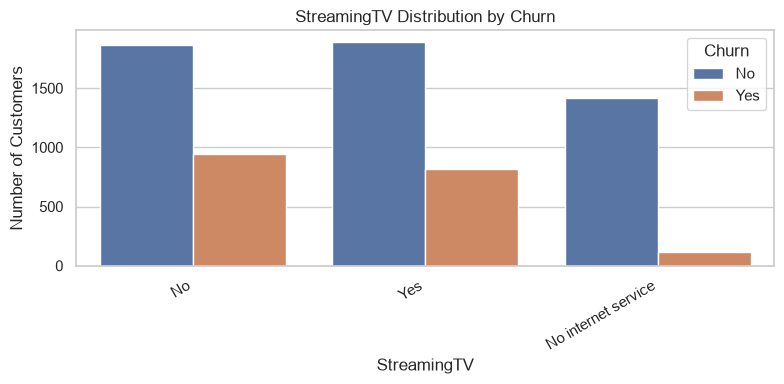

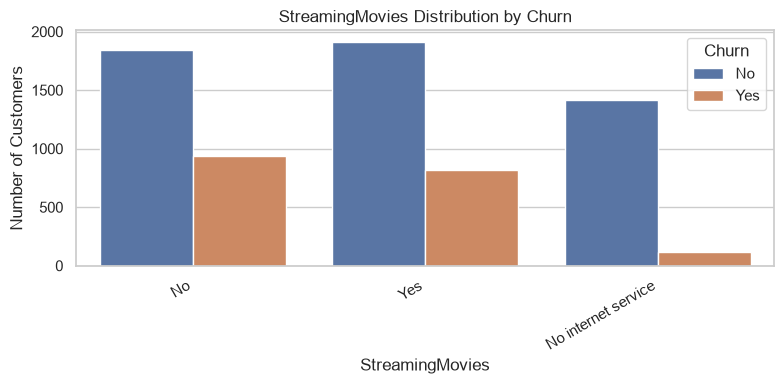

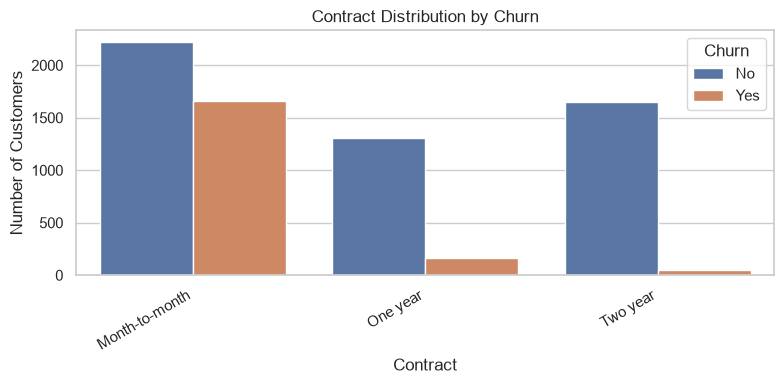

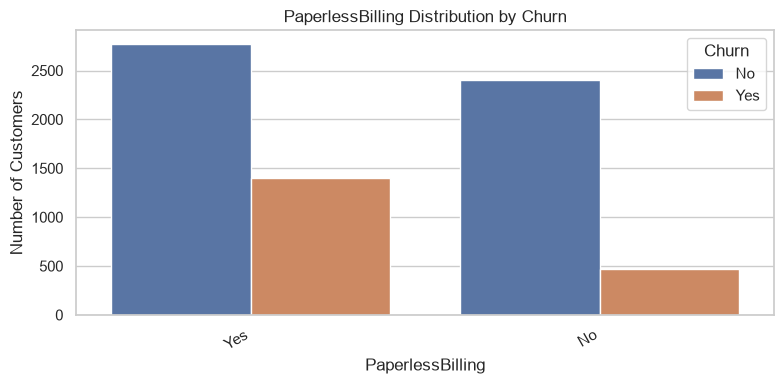

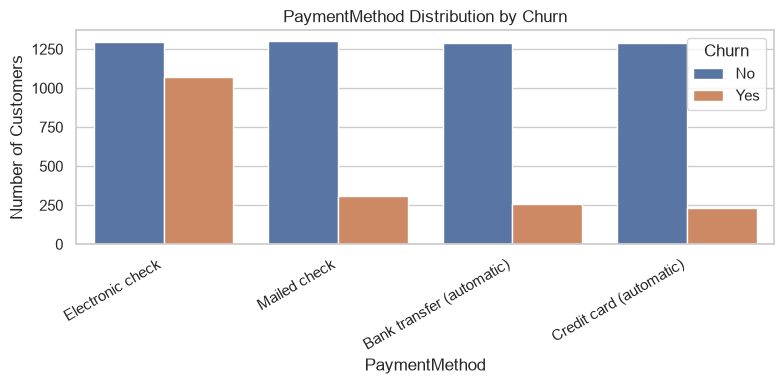

In [15]:
# ================================
# CATEGORICAL FEATURE DISTRIBUTIONS
# ================================

categorical_features = [
    col for col in df.select_dtypes(include="object").columns
    if col not in ["customerID", "Churn"]
]

for feature in categorical_features:

    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=df,
        x=feature,
        hue="Churn"
    )

    plt.title(f"{feature} Distribution by Churn")
    plt.xlabel(feature)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=30, ha="right")

    plt.tight_layout()
    plt.show()

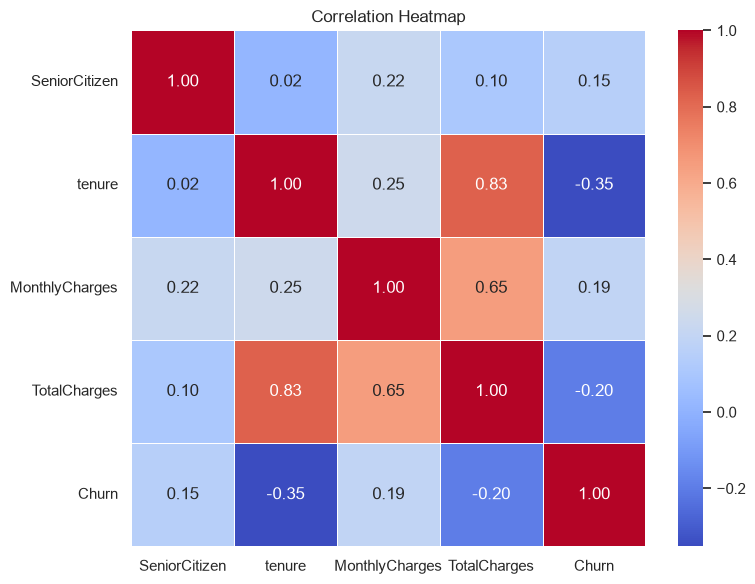

In [16]:
# ================================
# CORRELATION HEATMAP
# ================================

correlation_df = df[numerical_features].copy()

correlation_df["Churn"] = (
    df["Churn"]
    .map({"No": 0, "Yes": 1})
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [17]:
#Feature–Target Scatter Plots
# Numeric representation for visualization
df["Churn_Numeric"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

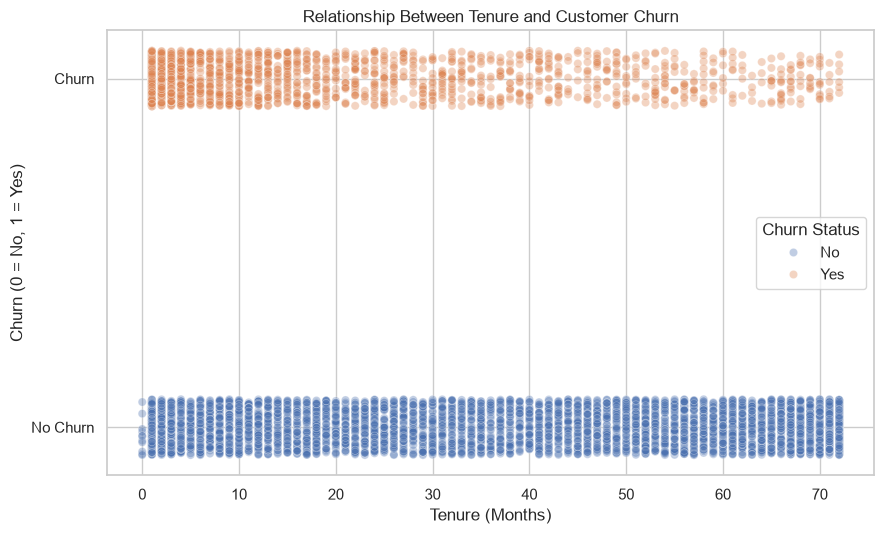

In [18]:
# ============================================
# SCATTER PLOT 1 — TENURE VS CUSTOMER CHURN
# ============================================

# Add small vertical jitter so overlapping binary target values
# can be visually distinguished.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

churn_jitter = (
    df["Churn_Numeric"]
    + np.random.uniform(-0.08, 0.08, size=len(df))
)

plt.figure(figsize=(9, 5.5))

sns.scatterplot(
    x=df["tenure"],
    y=churn_jitter,
    hue=df["Churn"],
    alpha=0.35,
    s=35
)

plt.title("Relationship Between Tenure and Customer Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn (0 = No, 1 = Yes)")

plt.yticks(
    [0, 1],
    ["No Churn", "Churn"]
)

plt.legend(
    title="Churn Status"
)

plt.tight_layout()
plt.show()

### Observation — Tenure vs Customer Churn

The scatter plot shows the distribution of churned and non-churned customers
across different tenure levels. Churned customers are more concentrated at
lower tenure values, while non-churned customers are distributed across a
wider range of tenure.

This suggests an association between customer tenure and churn, with newer
customers showing a greater tendency to churn in this dataset. However, the
plot alone does not establish a causal relationship.

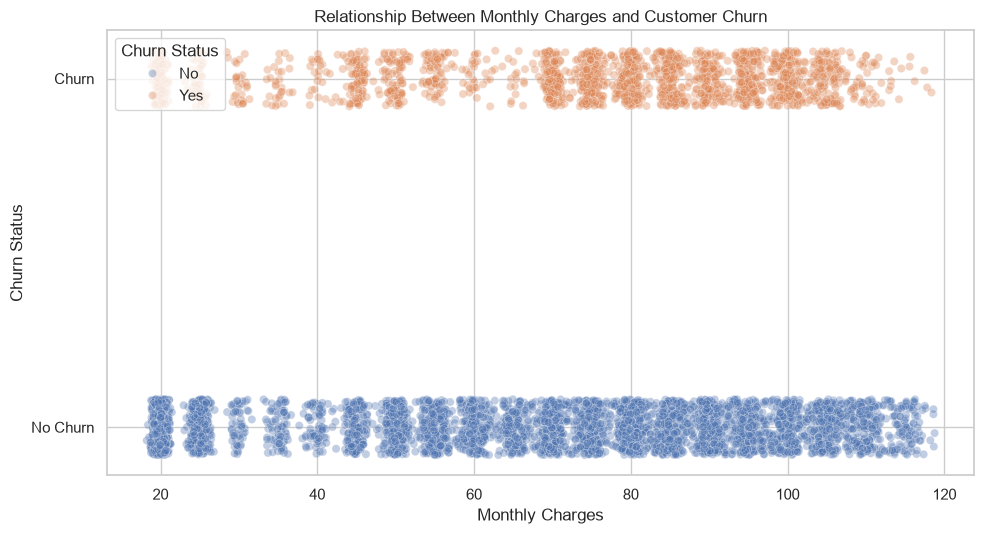

In [19]:
# ============================================
# SCATTER PLOT 2 — MONTHLY CHARGES VS CHURN
# ============================================

np.random.seed(RANDOM_STATE)

# Add small vertical jitter only for visualization.
# This prevents all binary target points from overlapping.

churn_jitter = (
    df["Churn_Numeric"]
    + np.random.uniform(-0.08, 0.08, size=len(df))
)

plt.figure(figsize=(10, 5.5))

sns.scatterplot(
    x=df["MonthlyCharges"],
    y=churn_jitter,
    hue=df["Churn"],
    alpha=0.35,
    s=35
)

plt.title("Relationship Between Monthly Charges and Customer Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Churn Status")

# Keep the target axis clean
plt.yticks(
    [0, 1],
    ["No Churn", "Churn"]
)

plt.legend(
    title="Churn Status",
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Observation — Monthly Charges vs Customer Churn

The scatter plot shows churned and non-churned customers across different
monthly charge levels. Churned customers appear across a broad range of
monthly charges, while the distribution of non-churned customers is also
spread across the charge range.

The plot indicates that monthly charges may contain useful information for
distinguishing churn behaviour, although there is substantial overlap between
the two classes. Therefore, monthly charges alone cannot clearly separate
churned and non-churned customers.

In [19]:
df.drop(columns=["Churn_Numeric"], inplace=True)

In [21]:
# ================================
# FEATURE ENGINEERING
# ================================

service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["ServiceCount"] = (
    df[service_columns] == "Yes"
).sum(axis=1)

print("ServiceCount created successfully.")

display(
    df[
        ["customerID", "ServiceCount", "Churn"]
    ].head()
)

ServiceCount created successfully.


,customerID,ServiceCount,Churn
0,7590-VHVEG,1,No
1,5575-GNVDE,3,No
2,3668-QPYBK,3,Yes
3,7795-CFOCW,3,No
4,9237-HQITU,1,Yes


### Feature Engineering — ServiceCount

A new feature named `ServiceCount` is created by counting the number of
telecommunication services subscribed to by each customer.

The motivation is that the number of services a customer uses may capture
the customer's overall engagement with the company. Customers with
different levels of service adoption may exhibit different churn
behaviour.

This feature is derived only from existing customer attributes and does
not use the target variable.

In [22]:
# ================================
# REMOVE IDENTIFIER
# ================================

df = df.drop(columns=["customerID"])

print("customerID removed because it is an identifier and has no meaningful predictive relationship.")

customerID removed because it is an identifier and has no meaningful predictive relationship.


In [23]:
# ================================
# DEFINE FEATURES AND TARGET
# ================================

X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (7043, 21)
Target shape: (7043,)


In [24]:
# ================================
# STRATIFIED TRAIN-TEST SPLIT
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 5634
Testing samples : 1409

Training target distribution:
Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64

Testing target distribution:
Churn
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64


In [25]:
# ================================
# OUTLIER CHECK
# ================================

numeric_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ServiceCount"
]

outlier_summary = []

for col in numeric_columns:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = (
        (X_train[col] < lower) |
        (X_train[col] > upper)
    ).sum()

    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": count
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df)

,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count
0,SeniorCitizen,0.0000,0.000,0.00000,0.00000,920
1,tenure,9.0000,55.000,-60.00000,124.00000,0
2,MonthlyCharges,35.6625,90.000,-45.84375,171.50625,0
3,TotalCharges,402.9750,3835.825,-4746.30000,8985.10000,0
4,ServiceCount,1.0000,5.000,-5.00000,11.00000,0


In [26]:
# ================================
# IQR-BASED OUTLIER TREATMENT
# FIT BOUNDS ONLY ON TRAINING DATA
# ================================

X_train = X_train.copy()
X_test = X_test.copy()

outlier_bounds = {}

for col in numeric_columns:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_bounds[col] = (lower, upper)

    X_train[col] = X_train[col].clip(
        lower=lower,
        upper=upper
    )

    X_test[col] = X_test[col].clip(
        lower=lower,
        upper=upper
    )

print("Outlier treatment completed using training-set IQR bounds.")

Outlier treatment completed using training-set IQR bounds.


In [27]:
# ================================
# FEATURE TYPES
# ================================

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Numeric', 'ServiceCount']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [28]:
# ================================
# PREPROCESSING PIPELINES
# ================================

numeric_transformer_scaled = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

numeric_transformer_unscaled = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [29]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_scaled,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [30]:
preprocessor_unscaled = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_unscaled,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [31]:
# ================================
# MODEL 1 — LOGISTIC REGRESSION
# ================================

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

logistic_pipeline.fit(X_train, y_train)

logistic_pred = logistic_pipeline.predict(X_test)
logistic_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [33]:
# ================================
# MODEL 2 — KNN
# ================================

knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        (
            "classifier",
            KNeighborsClassifier()
        )
    ]
)

knn_param_grid = {
    "classifier__n_neighbors": [3, 5, 7, 9, 11],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

knn_model = knn_grid.best_estimator_

knn_pred = knn_model.predict(X_test)
knn_prob = knn_model.predict_proba(X_test)[:, 1]

print("Best KNN Parameters:")
print(knn_grid.best_params_)

print("\nBest Cross-Validation Weighted F1:")
print(round(knn_grid.best_score_, 4))

Best KNN Parameters:
{'classifier__metric': 'euclidean', 'classifier__n_neighbors': 3, 'classifier__weights': 'uniform'}

Best Cross-Validation Weighted F1:
0.9988


In [34]:
# ================================
# MODEL 3 — GAUSSIAN NAIVE BAYES
# ================================

nb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        (
            "classifier",
            GaussianNB()
        )
    ]
)

nb_param_grid = {
    "classifier__var_smoothing": [
        1e-11,
        1e-9,
        1e-7
    ]
}

nb_grid = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=nb_param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1
)

nb_grid.fit(X_train, y_train)

nb_model = nb_grid.best_estimator_

nb_pred = nb_model.predict(X_test)
nb_prob = nb_model.predict_proba(X_test)[:, 1]

print("Best Naive Bayes Parameters:")
print(nb_grid.best_params_)

Best Naive Bayes Parameters:
{'classifier__var_smoothing': 1e-11}


In [35]:
# ================================
# MODEL 4 — DECISION TREE
# ================================

dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_unscaled),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)

dt_param_grid = {
    "classifier__max_depth": [
        3, 5, 7, 10, None
    ],
    "classifier__min_samples_split": [
        2, 5, 10
    ]
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

dt_model = dt_grid.best_estimator_

dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

Best Decision Tree Parameters:
{'classifier__max_depth': 3, 'classifier__min_samples_split': 2}


In [36]:
# ================================
# MODEL 5 — SUPPORT VECTOR MACHINE
# ================================

svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        (
            "classifier",
            SVC(
                probability=True,
                random_state=RANDOM_STATE
            )
        )
    ]
)

svm_param_grid = {
    "classifier__C": [0.1, 1, 10],
    "classifier__kernel": ["linear", "rbf"]
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

svm_model = svm_grid.best_estimator_

svm_pred = svm_model.predict(X_test)
svm_prob = svm_model.predict_proba(X_test)[:, 1]

print("Best SVM Parameters:")
print(svm_grid.best_params_)

Best SVM Parameters:
{'classifier__C': 0.1, 'classifier__kernel': 'linear'}


In [37]:
# ============================================
# HYPERPARAMETER TUNING — KNN
# ============================================

knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        ("classifier", KNeighborsClassifier())
    ]
)

knn_param_grid = {
    "classifier__n_neighbors": [3, 5, 7, 9, 11],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    return_train_score=False
)

knn_grid.fit(X_train, y_train)

knn_model = knn_grid.best_estimator_

knn_pred = knn_model.predict(X_test)
knn_prob = knn_model.predict_proba(X_test)[:, 1]

print("KNN tuning completed successfully.")
print("\nBest Parameters:")
print(knn_grid.best_params_)

print("\nBest 5-Fold CV Weighted F1:")
print(f"{knn_grid.best_score_:.4f}")

KNN tuning completed successfully.

Best Parameters:
{'classifier__metric': 'euclidean', 'classifier__n_neighbors': 3, 'classifier__weights': 'uniform'}

Best 5-Fold CV Weighted F1:
0.9988


In [38]:
# ============================================
# KNN GRID SEARCH RESULTS
# ============================================

knn_cv_results = pd.DataFrame(
    knn_grid.cv_results_
)

knn_cv_results = (
    knn_cv_results[
        [
            "param_classifier__n_neighbors",
            "param_classifier__weights",
            "param_classifier__metric",
            "mean_test_score",
            "std_test_score"
        ]
    ]
    .sort_values("mean_test_score", ascending=False)
)

display(
    knn_cv_results.head(10).style.format({
        "mean_test_score": "{:.4f}",
        "std_test_score": "{:.4f}"
    })
)

,param_classifier__n_neighbors,param_classifier__weights,param_classifier__metric,mean_test_score,std_test_score
0,3,uniform,euclidean,0.9988,0.0004
1,3,distance,euclidean,0.9988,0.0004
2,5,uniform,euclidean,0.9980,0.0009
3,5,distance,euclidean,0.9980,0.0009
5,7,distance,euclidean,0.9979,0.0009
8,11,uniform,euclidean,0.9977,0.0004
9,11,distance,euclidean,0.9977,0.0004
7,9,distance,euclidean,0.9977,0.0007
4,7,uniform,euclidean,0.9977,0.0012
6,9,uniform,euclidean,0.9975,0.0010


In [39]:
# ============================================
# HYPERPARAMETER TUNING — SVM
# ============================================

svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        (
            "classifier",
            SVC(
                probability=True,
                random_state=RANDOM_STATE
            )
        )
    ]
)

svm_param_grid = {
    "classifier__C": [0.1, 1, 10, 100],
    "classifier__kernel": ["linear", "rbf"]
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    return_train_score=False
)

svm_grid.fit(X_train, y_train)

svm_model = svm_grid.best_estimator_

svm_pred = svm_model.predict(X_test)
svm_prob = svm_model.predict_proba(X_test)[:, 1]

print("SVM tuning completed successfully.")
print("\nBest Parameters:")
print(svm_grid.best_params_)

print("\nBest 5-Fold CV Weighted F1:")
print(f"{svm_grid.best_score_:.4f}")

SVM tuning completed successfully.

Best Parameters:
{'classifier__C': 0.1, 'classifier__kernel': 'linear'}

Best 5-Fold CV Weighted F1:
1.0000


In [40]:
# ============================================
# SVM GRID SEARCH RESULTS
# ============================================

svm_cv_results = pd.DataFrame(
    svm_grid.cv_results_
)

svm_cv_results = (
    svm_cv_results[
        [
            "param_classifier__C",
            "param_classifier__kernel",
            "mean_test_score",
            "std_test_score"
        ]
    ]
    .sort_values("mean_test_score", ascending=False)
)

display(
    svm_cv_results.style.format({
        "mean_test_score": "{:.4f}",
        "std_test_score": "{:.4f}"
    })
)

,param_classifier__C,param_classifier__kernel,mean_test_score,std_test_score
0,0.100000,linear,1.0000,0.0000
1,0.100000,rbf,1.0000,0.0000
2,1.000000,linear,1.0000,0.0000
3,1.000000,rbf,1.0000,0.0000
4,10.000000,linear,1.0000,0.0000
5,10.000000,rbf,1.0000,0.0000
6,100.000000,linear,1.0000,0.0000
7,100.000000,rbf,1.0000,0.0000


In [37]:
# ================================
# STORE ALL MODELS
# ================================

models = {
    "Logistic Regression": (
        logistic_model,
        logistic_pred,
        logistic_prob
    ),
    
    "KNN": (
        knn_model,
        knn_pred,
        knn_prob
    ),
    
    "Gaussian Naive Bayes": (
        nb_model,
        nb_pred,
        nb_prob
    ),
    
    "Decision Tree": (
        dt_model,
        dt_pred,
        dt_prob
    ),
    
    "SVM": (
        svm_model,
        svm_pred,
        svm_prob
    )
}

print("All five classification models are ready for evaluation.")

All five classification models are ready for evaluation.


In [38]:
# ================================
# EVALUATION FUNCTION
# ================================

def evaluate_classifier(model_name, y_true, y_pred, y_prob):

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            pos_label="Yes"
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            pos_label="Yes"
        ),
        "F1-Weighted": f1_score(
            y_true,
            y_pred,
            average="weighted"
        ),
        "ROC-AUC": roc_auc_score(
            (y_true == "Yes").astype(int),
            y_prob
        )
    }

In [39]:
# ================================
# MODEL COMPARISON
# ================================

results = []

for model_name, (_, predictions, probabilities) in models.items():

    result = evaluate_classifier(
        model_name,
        y_test,
        predictions,
        probabilities
    )

    results.append(result)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1-Weighted",
    ascending=False
).reset_index(drop=True)

display(
    results_df.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Weighted": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-Weighted,ROC-AUC
0,Decision Tree,0.7956,0.6405,0.5241,0.7886,0.8302
1,Logistic Regression,0.7921,0.6262,0.5374,0.7867,0.8394
2,SVM,0.7935,0.6487,0.4840,0.7830,0.7970
3,KNN,0.7601,0.5503,0.5267,0.7584,0.8110
4,Gaussian Naive Bayes,0.6955,0.4595,0.8342,0.7133,0.8055


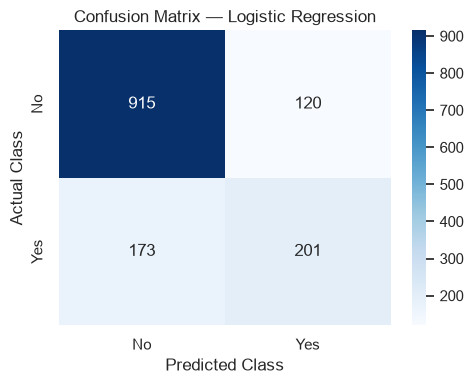

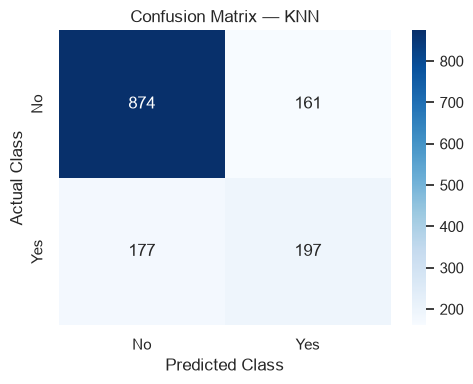

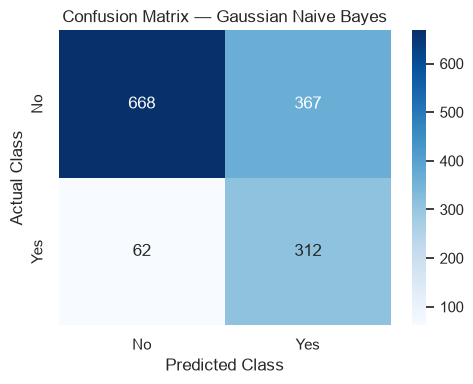

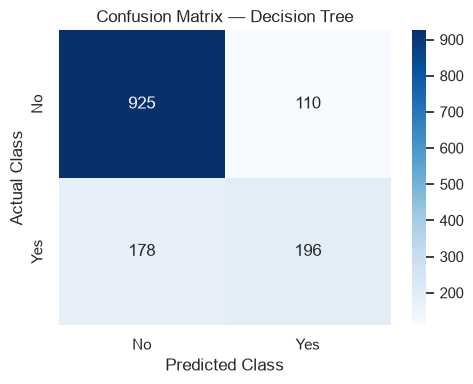

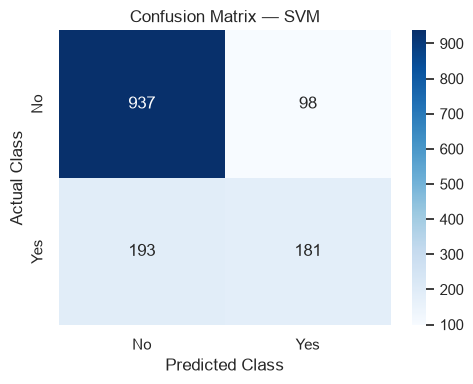

In [40]:
# ================================
# CONFUSION MATRICES
# ================================

for model_name, (_, predictions, _) in models.items():

    cm = confusion_matrix(
        y_test,
        predictions,
        labels=["No", "Yes"]
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"]
    )

    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.tight_layout()
    plt.show()

In [41]:
# ================================
# CLASSIFICATION REPORTS
# ================================

for model_name, (_, predictions, _) in models.items():

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions,
            digits=4
        )
    )

Logistic Regression
              precision    recall  f1-score   support

          No     0.8410    0.8841    0.8620      1035
         Yes     0.6262    0.5374    0.5784       374

    accuracy                         0.7921      1409
   macro avg     0.7336    0.7107    0.7202      1409
weighted avg     0.7840    0.7921    0.7867      1409

KNN
              precision    recall  f1-score   support

          No     0.8316    0.8444    0.8380      1035
         Yes     0.5503    0.5267    0.5383       374

    accuracy                         0.7601      1409
   macro avg     0.6909    0.6856    0.6881      1409
weighted avg     0.7569    0.7601    0.7584      1409

Gaussian Naive Bayes
              precision    recall  f1-score   support

          No     0.9151    0.6454    0.7569      1035
         Yes     0.4595    0.8342    0.5926       374

    accuracy                         0.6955      1409
   macro avg     0.6873    0.7398    0.6748      1409
weighted avg     0.7941    0.

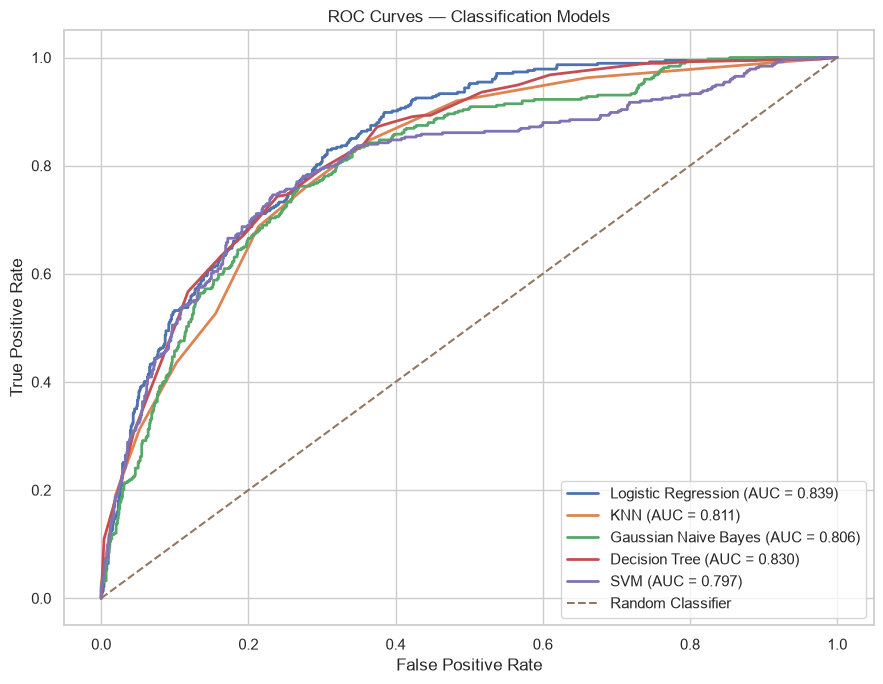

In [42]:
# ================================
# ROC CURVES
# ================================

plt.figure(figsize=(9, 7))

for model_name, (_, _, probabilities) in models.items():

    y_binary = (y_test == "Yes").astype(int)

    fpr, tpr, _ = roc_curve(
        y_binary,
        probabilities
    )

    auc_score = roc_auc_score(
        y_binary,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curves — Classification Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

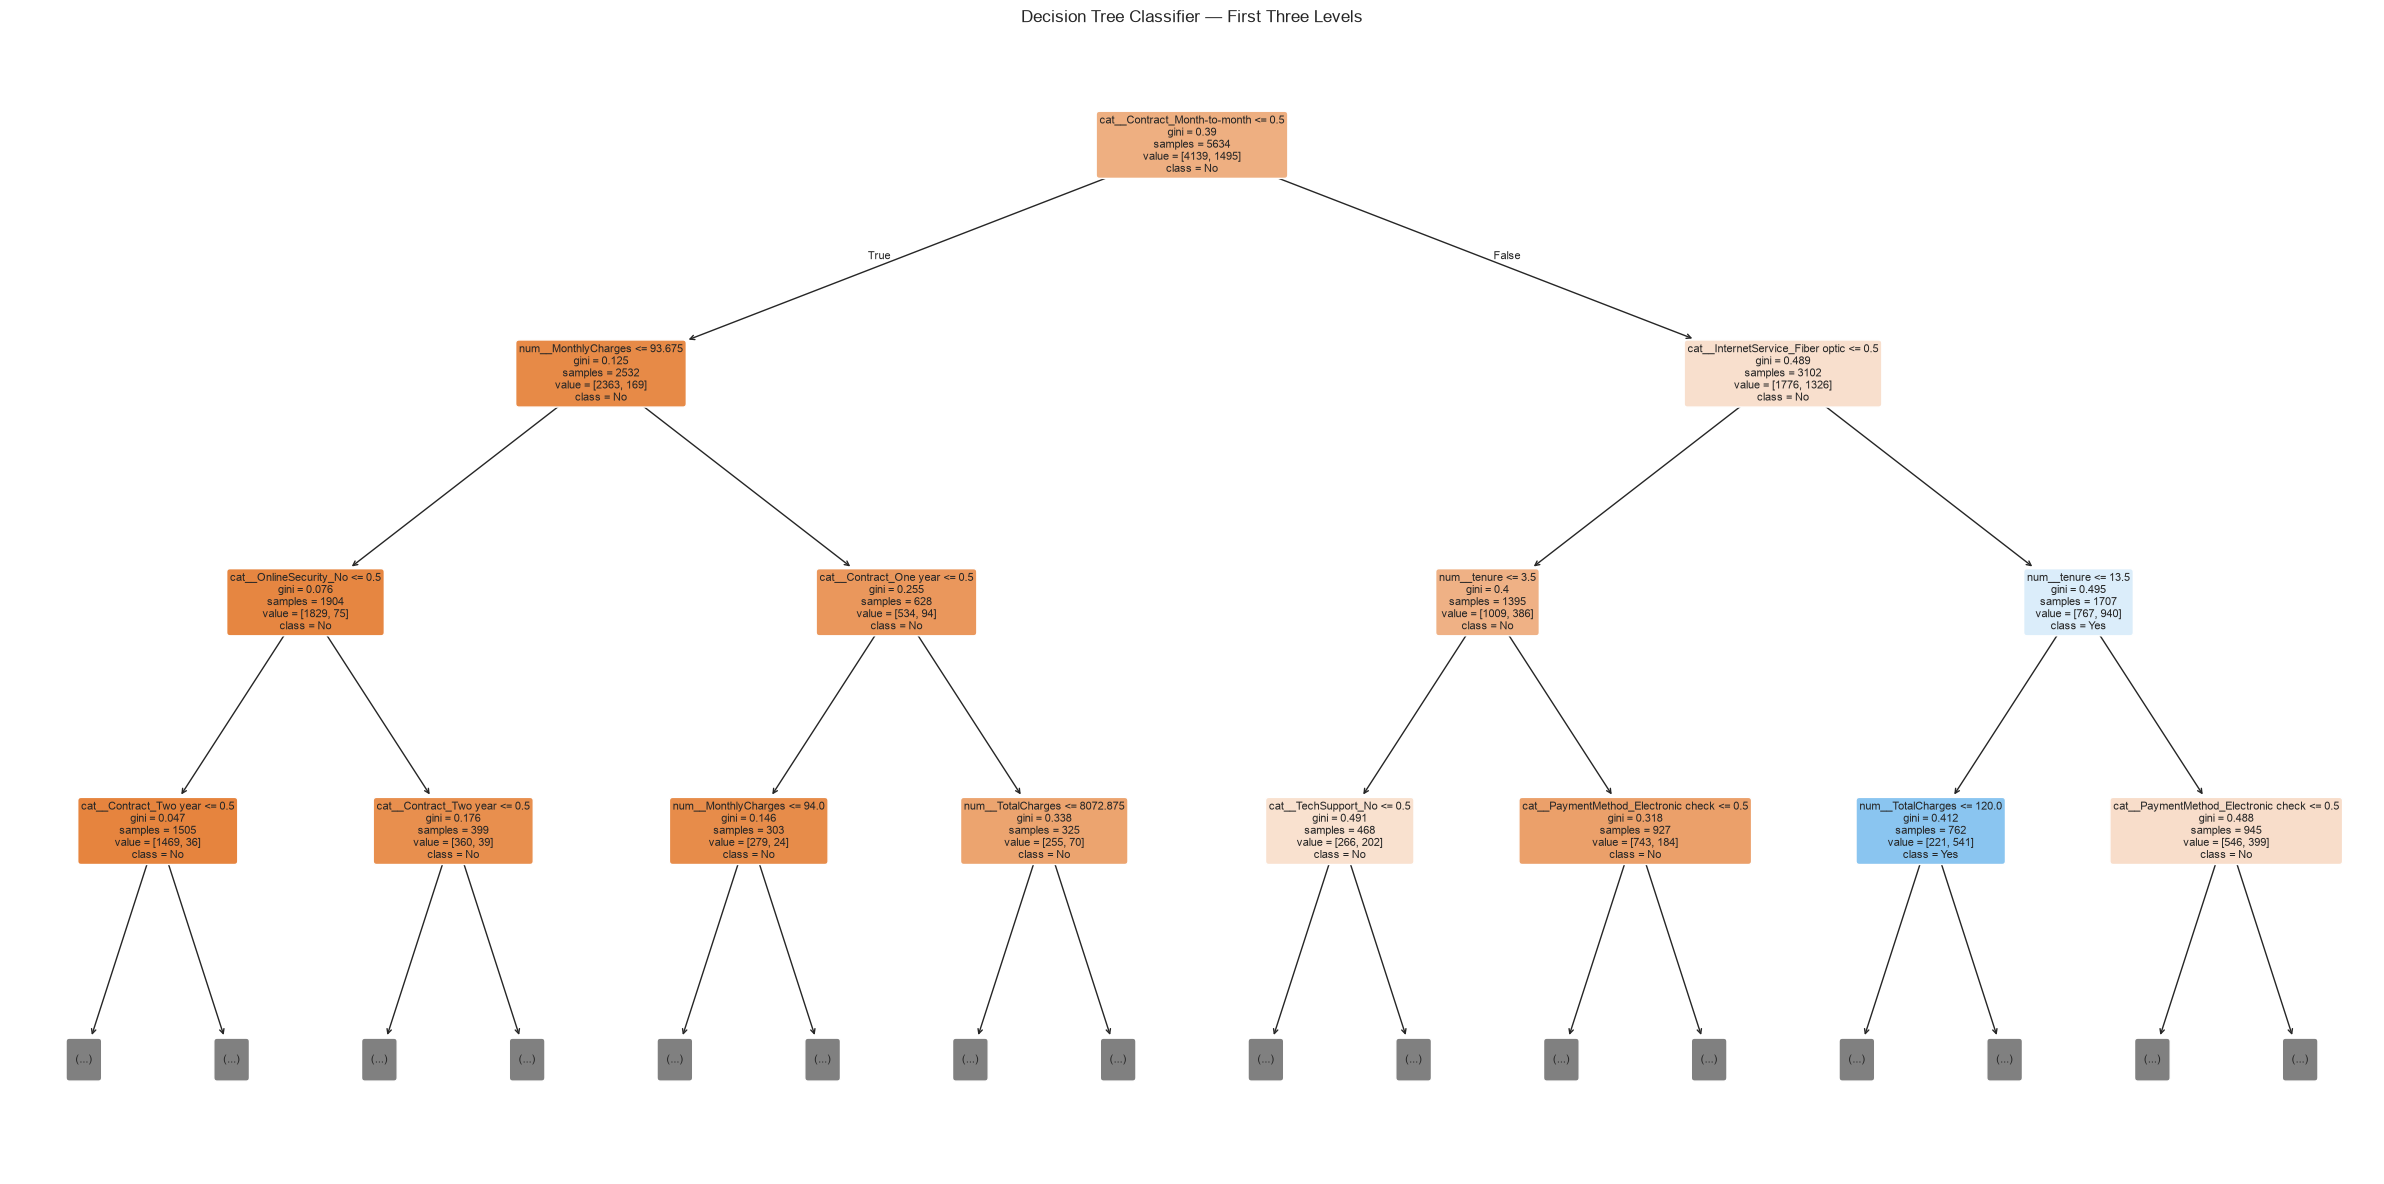

In [43]:
# ================================
# DECISION TREE VISUALIZATION
# ================================

dt_preprocessor = dt_model.named_steps["preprocessor"]
dt_classifier = dt_model.named_steps["classifier"]

feature_names = (
    dt_preprocessor
    .get_feature_names_out()
)

plt.figure(figsize=(24, 12))

plot_tree(
    dt_classifier,
    feature_names=feature_names,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Classifier — First Three Levels")
plt.tight_layout()
plt.show()

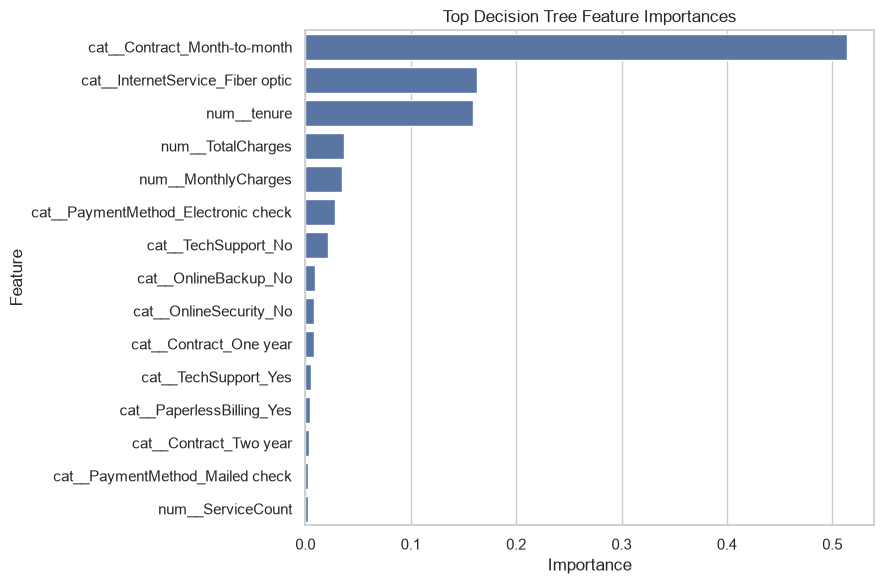

In [44]:
# ================================
# DECISION TREE FEATURE IMPORTANCE
# ================================

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": dt_classifier.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Top Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [45]:
# ================================
# LOGISTIC REGRESSION COEFFICIENTS
# ================================

log_preprocessor = logistic_model.named_steps["preprocessor"]
log_classifier = logistic_model.named_steps["classifier"]

log_feature_names = (
    log_preprocessor
    .get_feature_names_out()
)

coefficients = log_classifier.coef_[0]

logistic_coefficients = pd.DataFrame({
    "Feature": log_feature_names,
    "Coefficient": coefficients,
    "Odds_Ratio": np.exp(coefficients)
})

logistic_coefficients["Absolute_Coefficient"] = (
    logistic_coefficients["Coefficient"].abs()
)

logistic_coefficients = (
    logistic_coefficients
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
)

display(
    logistic_coefficients
    .head(15)
)

,Feature,Coefficient,Odds_Ratio,Absolute_Coefficient
2,num__MonthlyCharges,-2.543844,0.078564,2.543844
17,cat__InternetService_Fiber optic,1.514552,4.547382,1.514552
16,cat__InternetService_DSL,-1.396643,0.247426,1.396643
1,num__tenure,-1.314148,0.268703,1.314148
4,num__ServiceCount,0.945418,2.573888,0.945418
39,cat__Contract_Two year,-0.837428,0.432822,0.837428
3,num__TotalCharges,0.598690,1.819733,0.598690
18,cat__InternetService_No,-0.568839,0.566182,0.568839
29,cat__TechSupport_No internet service,-0.568839,0.566182,0.568839
26,cat__DeviceProtection_No internet service,-0.568839,0.566182,0.568839


In [46]:
# ================================
# TOP TWO MODELS
# ================================

top_two_models = results_df.head(2)["Model"].tolist()

print("Top two models based on weighted F1-score:")
for i, model_name in enumerate(top_two_models, 1):
    print(f"{i}. {model_name}")

Top two models based on weighted F1-score:
1. Decision Tree
2. Logistic Regression


In [47]:
# ================================
# 5-FOLD CROSS VALIDATION
# ================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = []

for model_name in top_two_models:

    model = models[model_name][0]

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_weighted",
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "Mean CV F1-Weighted": scores.mean(),
        "Std CV F1-Weighted": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

display(
    cv_results_df.style.format({
        "Mean CV F1-Weighted": "{:.4f}",
        "Std CV F1-Weighted": "{:.4f}"
    })
)

,Model,Mean CV F1-Weighted,Std CV F1-Weighted
0,Decision Tree,0.7829,0.0115
1,Logistic Regression,0.8002,0.0125


In [48]:
# ================================
# BEST HYPERPARAMETERS
# ================================

best_parameters = {
    "Logistic Regression": logistic_grid.best_params_,
    "KNN": knn_grid.best_params_,
    "Gaussian Naive Bayes": nb_grid.best_params_,
    "Decision Tree": dt_grid.best_params_,
    "SVM": svm_grid.best_params_
}

for model_name, params in best_parameters.items():

    print(f"\n{model_name}")
    print("-" * len(model_name))
    print(params)


Logistic Regression
-------------------
{'classifier__C': 100}

KNN
---
{'classifier__metric': 'euclidean', 'classifier__n_neighbors': 11, 'classifier__weights': 'uniform'}

Gaussian Naive Bayes
--------------------
{'classifier__var_smoothing': 1e-11}

Decision Tree
-------------
{'classifier__max_depth': 5, 'classifier__min_samples_split': 2}

SVM
---
{'classifier__C': 1, 'classifier__kernel': 'rbf'}


In [49]:
# ================================
# FINAL MODEL SUMMARY
# ================================

best_model_row = results_df.iloc[0]

print("Classification Results Summary")
print("=" * 50)

print(
    f"Highest Weighted F1: "
    f"{best_model_row['Model']}"
)

print(
    f"Accuracy      : "
    f"{best_model_row['Accuracy']:.4f}"
)

print(
    f"Precision     : "
    f"{best_model_row['Precision']:.4f}"
)

print(
    f"Recall        : "
    f"{best_model_row['Recall']:.4f}"
)

print(
    f"Weighted F1   : "
    f"{best_model_row['F1-Weighted']:.4f}"
)

print(
    f"ROC-AUC       : "
    f"{best_model_row['ROC-AUC']:.4f}"
)

Classification Results Summary
Highest Weighted F1: Decision Tree
Accuracy      : 0.7956
Precision     : 0.6405
Recall        : 0.5241
Weighted F1   : 0.7886
ROC-AUC       : 0.8302
